# SRQ2 — NCA + kNN Pipeline Evaluation

Replaces the trained linear classifier head with a post-hoc NCA + kNN pipeline applied to 512-dimensional backbone embeddings. Evaluates whether metric-space classification improves over the linear head baseline, and whether the benefit differs across backbone architectures.

**Backbones evaluated (3 total):**
- `base` — plain ResNet18 (anchor comparison)
- `cbam_block_post` — best SRQ1 test F1 (0.9407), primary
- `cbam_isolated_end` — runner-up SRQ1 test F1 (0.9294), cross-backbone comparison

**Protocol:**
- **Parameter selection:** `target_dim` ∈ {64, 128, 256, 512} and `k` ∈ {1, 3, 5, 7, 9} selected independently per backbone via 3-fold CV in feature space.
- **Evaluation:** For each backbone, each of the 5 saved fold weights is loaded, 512-dim embeddings extracted, and NCA+kNN applied with that backbone's selected parameters.
- Results saved fold-by-fold to `nca-knn-results/nca_knn_results.csv` — safe to interrupt and resume.
- All plots saved as SVG for dissertation use.

## 1 · Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
ARCH_EVAL_DIR = PROJECT_ROOT / "data" / "experiments" / "arch-eval-results"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "nca-knn-results"
WEIGHTS_DIR   = ARCH_EVAL_DIR / "weights"
PLOTS_DIR     = RESULTS_DIR / "plots"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root  : {PROJECT_ROOT}")
print(f"Data dir      : {DATA_DIR}")
print(f"Arch-eval dir : {ARCH_EVAL_DIR}")
print(f"Results dir   : {RESULTS_DIR}")
print(f"Plots dir     : {PLOTS_DIR}")
print(f"Weights dir   : {WEIGHTS_DIR}")

Project root  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir      : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Arch-eval dir : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results
Results dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results
Plots dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\plots
Weights dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\weights


In [2]:
import csv
import itertools
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

import src.scripts.data      as data
import src.scripts.models    as models
import src.scripts.trainer   as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils     as utils

utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## 2 · Data — Identical Outer Split

Same seed-42 outer split as all other experiments. The held-out test set is set aside and not used until Section 8 (final evaluation).

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nNCA+kNN evaluation operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used until Section 8.")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

NCA+kNN evaluation operates on 1321 train+val samples.
Held-out test set is NOT used until Section 8.


## 3 · Configuration

In [4]:
# ── Load arch-eval results for linear head baseline ──────────────────────────
ARCH_RESULTS_FILE = ARCH_EVAL_DIR / "arch_eval_results.csv"
if not ARCH_RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"arch_eval_results.csv not found at {ARCH_RESULTS_FILE}\n"
        "Run the architecture evaluation notebook first."
    )

df_arch = pd.read_csv(ARCH_RESULTS_FILE)
df_arch["error"] = df_arch["error"].fillna("")
df_arch_ok = df_arch[df_arch["error"] == ""].copy()

linear_baseline = (
    df_arch_ok.groupby("architecture")["val_f1"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "linear_f1_mean", "std": "linear_f1_std"})
)
print("Linear head baselines (from arch-eval):\n")
print(linear_baseline.to_string())

Linear head baselines (from arch-eval):

                         linear_f1_mean  linear_f1_std
architecture                                          
base                           0.917381       0.027247
cbam_block_post                0.899055       0.029739
cbam_block_pre                 0.863452       0.057110
cbam_end                       0.925361       0.022225
cbam_isolated_block_pre        0.891668       0.033113
cbam_isolated_end              0.905087       0.033265
se_block_pre                   0.906957       0.030946
se_end                         0.904073       0.041417


In [5]:
# ── Load winning head ────────────────────────────────────────────────────────
OPTIMAL_HEAD_FILE = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results" / "optimal_head.csv"
if not OPTIMAL_HEAD_FILE.exists():
    raise FileNotFoundError(
        f"optimal_head.csv not found at {OPTIMAL_HEAD_FILE}\n"
        "Run the head ablation notebook first."
    )
optimal_head = pd.read_csv(OPTIMAL_HEAD_FILE).iloc[0]
WINNING_HEAD = optimal_head["head"]
print(f"Winning head : {WINNING_HEAD}")

Winning head : linear


In [6]:
# ── Backbones and search grid ─────────────────────────────────────────────────
BACKBONES = [
    "base",
    "cbam_end",
    "cbam_block_pre",
    "cbam_block_post",
    "se_end",
    "se_block_pre",
    "cbam_isolated_end",
    "cbam_isolated_block_pre",
]

N_SPLITS_EVAL   = 5    # matches arch-eval; reuses saved fold weights
N_SPLITS_SEARCH = 3    # inner CV folds for per-backbone parameter selection
SEED            = 42
BATCH_SIZE      = 32

TARGET_DIMS = [64, 128, 256, 512]
KS = list(range(1, 30, 2))

# ── Output ────────────────────────────────────────────────────────────────────
RESULTS_FILE    = RESULTS_DIR / "nca_knn_results.csv"
OPT_PARAMS_FILE = RESULTS_DIR / "optimal_params.csv"
CSV_FIELDNAMES  = [
    "backbone", "target_dim", "k",
    "fold", "nca_knn_f1", "linear_f1", "delta_f1",
    "timestamp", "error"
]
OPT_FIELDNAMES = ["backbone", "target_dim", "k", "mean_f1", "std_f1"]

print(f"Backbones      : {BACKBONES}")
print(f"Target dims    : {TARGET_DIMS}")
print(f"k values       : {KS}")
print(f"Eval folds     : {N_SPLITS_EVAL}")
print(f"Search folds   : {N_SPLITS_SEARCH}")
print(f"Results        → {RESULTS_FILE}")
print(f"Optimal params → {OPT_PARAMS_FILE}")

Backbones      : ['base', 'cbam_end', 'cbam_block_pre', 'cbam_block_post', 'se_end', 'se_block_pre', 'cbam_isolated_end', 'cbam_isolated_block_pre']
Target dims    : [64, 128, 256, 512]
k values       : [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
Eval folds     : 5
Search folds   : 3
Results        → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\nca_knn_results.csv
Optimal params → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\optimal_params.csv


## 4 · Helpers

In [7]:
def extract_features(backbone_name, fold_idx, train_loader, val_loader, device):
    """Load saved fold weights and extract 512-dim avgpool embeddings."""
    model = models.get_model(architecture=backbone_name, head=WINNING_HEAD)
    model = utils.load_weights(model, utils.weights_path_for(WEIGHTS_DIR, backbone_name, fold_idx), device=device)
    model.eval()
    X_train, y_train = trainer.get_features(model, train_loader, device=device)
    X_val,   y_val   = trainer.get_features(model, val_loader,   device=device)
    return X_train, y_train, X_val, y_val


def run_nca_knn_scored(X_train_raw, y_train, X_val_raw, y_val, target_dim, k):
    """
    StandardScaler → NCA(target_dim) → kNN(k, distance-weighted).
    Scaler and NCA fit on training data only — no leakage.
    Returns val F1.
    """
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_raw)
    X_va = scaler.transform(X_val_raw)
    X_tr_nca, X_va_nca = trainer.get_nca_features(
        X_tr, y_train, X_va, TARGET_DIM=target_dim, SEED=SEED
    )
    knn    = trainer.get_and_train_knn(X_tr_nca, y_train, NUM_NEIGHBOURS=k)
    y_pred = evaluator.predict_knn(knn, X_va_nca)
    return f1_score(y_val, y_pred, average="binary", zero_division=0)


def load_optimal_params():
    """Load saved per-backbone optimal parameters if they exist."""
    if OPT_PARAMS_FILE.exists():
        df = pd.read_csv(OPT_PARAMS_FILE)
        return {row["backbone"]: (int(row["target_dim"]), int(row["k"]))
                for _, row in df.iterrows()}
    return {}

## 5 · Parameter Selection (base backbone)

Grid search over `target_dim` ∈ {64, 128, 256, 512} and `k` ∈ {1, 3, 5, 7, 9} using 3-fold CV in feature space. Run on the `base` backbone only — the selected parameters are then applied uniformly to all three backbones.

**Why base only?** Using the same `(target_dim, k)` across all backbones means any difference in NCA+kNN F1 is attributable purely to backbone representation quality, not pipeline tuning. If each backbone had its own parameters, cross-backbone comparison would be confounded.

Features are extracted once using fold-0 weights as representative. The CV search operates entirely in numpy — no CNN retraining per grid point.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# Load any previously saved optimal params (resume support)
optimal_params   = load_optimal_params()
all_search_results = {}

# ── Parameter search on base backbone only ───────────────────────────────────
SEARCH_BACKBONE = "base"

if SEARCH_BACKBONE in optimal_params:
    td, k = optimal_params[SEARCH_BACKBONE]
    print(f"SKIP  {SEARCH_BACKBONE} — already selected: target_dim={td}  k={k}")
else:
    print(f"{'='*65}")
    print(f"  Parameter search — backbone: {SEARCH_BACKBONE}")
    print(f"{'='*65}")

    model = models.get_model(architecture=SEARCH_BACKBONE, head=WINNING_HEAD)
    # Uses fold 0 weights (fold 0 for 0 indexed, fold 1 for 1 indexed) as had best performance in arch-eval
    model = utils.load_weights( model, utils.weights_path_for(WEIGHTS_DIR, SEARCH_BACKBONE, 0), device=device)
    model.eval()

    all_loader = data.get_test_loader(
        X_trainval, y_trainval, test_transform, batch_size=BATCH_SIZE
    )
    print(f"  Extracting features from {len(X_trainval)} samples...")
    X_all, y_all = trainer.get_features(model, all_loader, device=device)
    print(f"  Feature matrix shape: {X_all.shape}")

    total_fits = len(TARGET_DIMS) * len(KS) * N_SPLITS_SEARCH
    print(f"  Grid: {len(TARGET_DIMS)} dims × {len(KS)} k values × {N_SPLITS_SEARCH} folds = {total_fits} NCA fits")

    search_rows = []
    skf   = StratifiedKFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
    X_arr = np.array(X_all)
    y_arr = np.array(y_all)

    for target_dim, k in itertools.product(TARGET_DIMS, KS):
        fold_f1s = []
        for tr_idx, va_idx in skf.split(X_arr, y_arr):
            try:
                f1 = run_nca_knn_scored(
                    X_arr[tr_idx], y_arr[tr_idx],
                    X_arr[va_idx], y_arr[va_idx],
                    target_dim, k
                )
                fold_f1s.append(f1)
            except Exception as e:
                print(f"    WARN target_dim={target_dim} k={k}: {e}")
                fold_f1s.append(0.0)

        mean_f1 = float(np.mean(fold_f1s))
        std_f1  = float(np.std(fold_f1s))
        search_rows.append({"target_dim": target_dim, "k": k,
                             "mean_f1": mean_f1, "std_f1": std_f1})
        print(f"    dim={target_dim:3d}  k={k}  F1={mean_f1:.4f} ± {std_f1:.4f}")

    df_search = (
        pd.DataFrame(search_rows)
        .sort_values(["mean_f1", "target_dim"], ascending=[False, True])
    )
    all_search_results[SEARCH_BACKBONE] = df_search

    best   = df_search.iloc[0]
    OPT_TD = int(best["target_dim"])
    OPT_K  = int(best["k"])
    optimal_params[SEARCH_BACKBONE] = (OPT_TD, OPT_K)

    print(f"\n  Selected: target_dim={OPT_TD}  k={OPT_K}  "
          f"mean_F1={best['mean_f1']:.4f} ± {best['std_f1']:.4f}")


    utils.append_result(
        OPT_PARAMS_FILE, OPT_FIELDNAMES,
        {"backbone": SEARCH_BACKBONE, "target_dim": OPT_TD, "k": OPT_K,
         "mean_f1": round(best["mean_f1"], 6), "std_f1": round(best["std_f1"], 6)}
    )

# ── Apply same params to all backbones ───────────────────────────────────────
OPT_TD, OPT_K = optimal_params[SEARCH_BACKBONE]
for backbone in BACKBONES:
    optimal_params[backbone] = (OPT_TD, OPT_K)

print(f"\n{'='*65}")
print(f"PARAMETER SELECTION COMPLETE")
print(f"Applying target_dim={OPT_TD}  k={OPT_K} to all backbones:")
for b in BACKBONES:
    print(f"  {b}")


Device: cpu

SKIP  base — already selected: target_dim=64  k=3

PARAMETER SELECTION COMPLETE
Applying target_dim=64  k=3 to all backbones:
  base
  cbam_end
  cbam_block_pre
  cbam_block_post
  se_end
  se_block_pre
  cbam_isolated_end
  cbam_isolated_block_pre


### 5.1 · Parameter Search Heatmap

Heatmap of mean val F1 across the `target_dim` × `k` grid for the `base` backbone. Selected configuration highlighted in orange.

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\plots\param_search_heatmap.svg


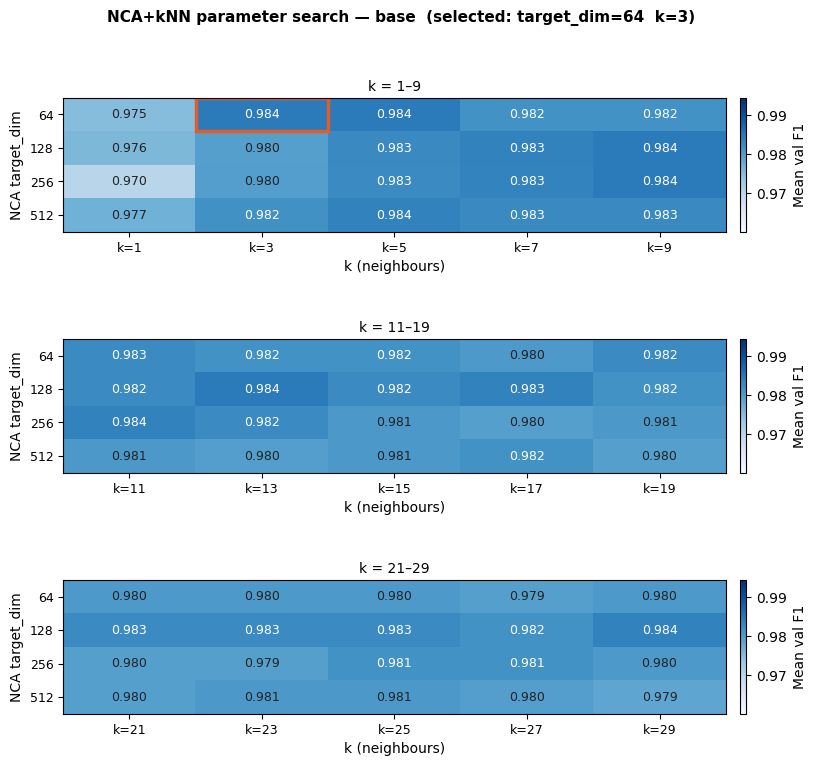


Top 10 configurations (sorted by mean val F1):



,target_dim,k,mean_f1,std_f1
rank,,,,
1,64,3,0.9845,0.0162
2,128,9,0.9845,0.0162
3,128,13,0.9845,0.0162
4,256,9,0.9845,0.0162
5,64,5,0.9844,0.0181
6,512,5,0.9836,0.0152
7,128,29,0.9835,0.0131
8,256,11,0.9835,0.0175
9,128,7,0.9835,0.0159


In [9]:
# Load search results if run in a previous session
if not all_search_results:
    search_csv = RESULTS_DIR / "param_search_results.csv"
    if search_csv.exists():
        df_s = pd.read_csv(search_csv)
        sub  = df_s[df_s["backbone"] == SEARCH_BACKBONE]
        if not sub.empty:
            all_search_results[SEARCH_BACKBONE] = sub[["target_dim", "k", "mean_f1", "std_f1"]]

if SEARCH_BACKBONE not in all_search_results:
    print("No search results yet — run Section 5 first.")
else:
    df_b          = all_search_results[SEARCH_BACKBONE]
    td_opt, k_opt = optimal_params.get(SEARCH_BACKBONE, (None, None))
    pivot         = df_b.pivot(index="target_dim", columns="k", values="mean_f1")

    all_k  = list(pivot.columns)
    n      = len(all_k)
    third  = n // 3
    k_splits = [all_k[:third], all_k[third:2*third], all_k[2*third:]]

    vmin = pivot.values.min() - 0.01
    vmax = pivot.values.max() + 0.01

    fig, axes = plt.subplots(3, 1, figsize=(9, 8),
                             gridspec_kw={"hspace": 0.8})
    fig.suptitle(
        f"NCA+kNN parameter search — {SEARCH_BACKBONE}  "
        f"(selected: target_dim={td_opt}  k={k_opt})",
        fontsize=11, fontweight="bold", y=0.99
    )

    for ax, k_cols in zip(axes, k_splits):
        subtitle = f"k = {k_cols[0]}–{k_cols[-1]}"
        sub = pivot[k_cols]
        im  = ax.imshow(sub.values, aspect="auto", cmap="Blues",
                        vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(k_cols)))
        ax.set_xticklabels([f"k={k}" for k in k_cols], fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([str(d) for d in pivot.index], fontsize=9)
        ax.set_xlabel("k (neighbours)", fontsize=10)
        ax.set_ylabel("NCA target_dim", fontsize=10)
        ax.set_title(subtitle, fontsize=10, pad=5)

        for i in range(len(pivot.index)):
            for j, k_val in enumerate(k_cols):
                val = pivot.loc[pivot.index[i], k_val]
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=9,
                        color="white" if val > pivot.values.mean() else "#222")

        if td_opt is not None and k_opt in k_cols:
            sel_row = list(pivot.index).index(td_opt)
            sel_col = k_cols.index(k_opt)
            ax.add_patch(plt.Rectangle(
                (sel_col - 0.5, sel_row - 0.5), 1, 1,
                fill=False, edgecolor="#E05C2A", linewidth=2.5
            ))

        fig.colorbar(im, ax=ax, label="Mean val F1",
                     fraction=0.03, pad=0.02)

    plt.savefig(str(PLOTS_DIR / "param_search_heatmap.svg"),
                format="svg", bbox_inches="tight")
    utils.save_fig(fig, PLOTS_DIR, "param_search_heatmap", formats=("svg",))
    plt.show()

    # ── Top 10 configurations table ──────────────────────────────────────
    print("\nTop 10 configurations (sorted by mean val F1):\n")
    df_top10 = (
        df_b
        .sort_values(["mean_f1", "target_dim"], ascending=[False, True])
        .head(10)
        .round(4)
        .reset_index(drop=True)
    )
    df_top10.index += 1
    df_top10.index.name = "rank"
    display(df_top10)

In [10]:
# Save full search table to CSV
if SEARCH_BACKBONE in all_search_results:
    df_save     = all_search_results[SEARCH_BACKBONE].copy()
    df_save.insert(0, "backbone", SEARCH_BACKBONE)
    search_path = RESULTS_DIR / "param_search_results.csv"
    df_save.to_csv(search_path, index=False)
    print(f"Search table saved → {search_path}")


Search table saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\param_search_results.csv


## 6 · NCA + kNN Evaluation — All Three Backbones

For each backbone × fold: load saved arch-eval weights, extract 512-dim embeddings from that fold's train/val split, apply the NCA+kNN pipeline with the shared `(target_dim, k)` selected on `base` in Section 5, and compute val F1 and Δ against the linear head baseline.

Results written fold-by-fold — safe to interrupt and resume.

In [11]:
# Verify all optimal params are available before starting
if SEARCH_BACKBONE not in optimal_params:
    raise RuntimeError(
        "optimal_params not found — run Section 5 first to complete parameter selection."
    )
OPT_TD, OPT_K = optimal_params[SEARCH_BACKBONE]

completed_runs = utils.load_completed_runs(RESULTS_FILE, [("backbone", str), ("fold", int)])
run_number     = len(completed_runs)
total_runs     = len(BACKBONES) * N_SPLITS_EVAL

print(f"{len(BACKBONES)} backbones × {N_SPLITS_EVAL} folds = {total_runs} runs")
print(f"Already completed : {len(completed_runs)}")
print()
for b in BACKBONES:
    td, k = optimal_params[b]
    print(f"  {b:<30} target_dim={td}  k={k}")
print(f"\nResults → {RESULTS_FILE}\n")

for backbone in BACKBONES:
    td_opt, k_opt = OPT_TD, OPT_K

    for fold_idx in range(N_SPLITS_EVAL):

        run_key = (backbone, fold_idx)
        if run_key in completed_runs:
            print(f"SKIP  backbone={backbone}  fold={fold_idx+1}/{N_SPLITS_EVAL}")
            continue

        utils.set_seed(SEED)
        run_number += 1
        print(f"\n{'='*65}")
        print(f"  Run {run_number}/{total_runs}  |  backbone={backbone}  "              f"fold={fold_idx+1}/{N_SPLITS_EVAL}  "              f"[dim={td_opt}  k={k_opt}]")
        print(f"{'='*65}")

        try:
            train_loader, val_loader = data.get_fold_loaders(
                X_trainval, y_trainval,
                fold_idx=fold_idx,
                train_transform=train_transform,
                test_transform=test_transform,
                n_splits=N_SPLITS_EVAL,
                batch_size=BATCH_SIZE,
                SEED=SEED
            )

            X_train_raw, y_train_feat, X_val_raw, y_val_feat = extract_features(
                backbone, fold_idx, train_loader, val_loader, device
            )
            print(f"  Train: {X_train_raw.shape}   Val: {X_val_raw.shape}")

            nca_knn_f1 = run_nca_knn_scored(
                X_train_raw, y_train_feat,
                X_val_raw,   y_val_feat,
                target_dim=td_opt, k=k_opt
            )

            arch_fold_rows = df_arch_ok[
                (df_arch_ok["architecture"] == backbone) &
                (df_arch_ok["fold"] == fold_idx)
            ]
            linear_f1 = float(arch_fold_rows["val_f1"].iloc[0])                         if len(arch_fold_rows) else float("nan")
            delta_f1  = nca_knn_f1 - linear_f1                         if not np.isnan(linear_f1) else float("nan")

            row = {
                "backbone"  : backbone,
                "target_dim": td_opt,
                "k"         : k_opt,
                "fold"      : fold_idx,
                "nca_knn_f1": round(nca_knn_f1, 6),
                "linear_f1" : round(linear_f1,  6),
                "delta_f1"  : round(delta_f1,   6),
                "timestamp" : datetime.now().isoformat(timespec="seconds"),
                "error"     : "",
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, row)
            completed_runs.add(run_key)

            print(f"  nca_knn_f1={nca_knn_f1:.4f}  "                  f"linear_f1={linear_f1:.4f}  Δ={delta_f1:+.4f}")

        except Exception as e:
            error_msg = f"{type(e).__name__}: {str(e)}"
            print(f"ERROR -- {error_msg}")
            traceback.print_exc()
            error_row = {
                "backbone": backbone, "target_dim": td_opt, "k": k_opt,
                "fold": fold_idx, "nca_knn_f1": "", "linear_f1": "",
                "delta_f1": "",
                "timestamp": datetime.now().isoformat(timespec="seconds"),
                "error": error_msg,
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, error_row)

print(f"\n{'='*65}")
print("NCA+kNN EVALUATION COMPLETE")
print(f"Results → {RESULTS_FILE}")

8 backbones × 5 folds = 40 runs
Already completed : 40

  base                           target_dim=64  k=3
  cbam_end                       target_dim=64  k=3
  cbam_block_pre                 target_dim=64  k=3
  cbam_block_post                target_dim=64  k=3
  se_end                         target_dim=64  k=3
  se_block_pre                   target_dim=64  k=3
  cbam_isolated_end              target_dim=64  k=3
  cbam_isolated_block_pre        target_dim=64  k=3

Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\nca_knn_results.csv

SKIP  backbone=base  fold=1/5
SKIP  backbone=base  fold=2/5
SKIP  backbone=base  fold=3/5
SKIP  backbone=base  fold=4/5
SKIP  backbone=base  fold=5/5
SKIP  backbone=cbam_end  fold=1/5
SKIP  backbone=cbam_end  fold=2/5
SKIP  backbone=cbam_end  fold=3/5
SKIP  backbone=cbam_end  fold=4/5
SKIP  backbone=cbam_end  fold=5/5
SKIP  backbone=cbam_block_pre  fold=1/5
SKIP  backbone=cbam_block_pre  fold=2/5
SKIP  ba

## 7 · Results Analysis

CV summary and per-fold breakdown — confirms the pipeline ran correctly and shows fold-level variance. Visualisations are in Section 8 (test set only).

In [12]:
df_raw = pd.read_csv(RESULTS_FILE)
df_raw["error"] = df_raw["error"].fillna("")
df_ok   = df_raw[df_raw["error"] == ""].copy()
df_fail = df_raw[df_raw["error"] != ""].copy()

for col in ["nca_knn_f1", "linear_f1", "delta_f1"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail) > 0:
    print(df_fail[["backbone", "fold", "error"]].to_string(index=False))

Successful runs : 40 / 40
Failed runs     : 0


In [13]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = (
    df_ok.groupby("backbone")
    .agg(
        nca_knn_f1_mean = ("nca_knn_f1", "mean"),
        nca_knn_f1_std  = ("nca_knn_f1", "std"),
        linear_f1_mean  = ("linear_f1",  "mean"),
        linear_f1_std   = ("linear_f1",  "std"),
        delta_f1_mean   = ("delta_f1",   "mean"),
        delta_f1_std    = ("delta_f1",   "std"),
        n_folds         = ("nca_knn_f1", "count"),
    )
    .reset_index()
)

backbone_order = {b: i for i, b in enumerate(BACKBONES)}
summary["_order"] = summary["backbone"].map(backbone_order)
summary = summary.sort_values("_order").drop(columns="_order")

# Attach selected params
summary["target_dim"] = summary["backbone"].map(
    lambda b: optimal_params.get(b, (None, None))[0])
summary["k"] = summary["backbone"].map(
    lambda b: optimal_params.get(b, (None, None))[1])

summary["NCA+kNN F1"] = summary.apply(
    lambda r: f"{r.nca_knn_f1_mean:.4f} ± {r.nca_knn_f1_std:.4f}", axis=1)
summary["Linear F1"]  = summary.apply(
    lambda r: f"{r.linear_f1_mean:.4f} ± {r.linear_f1_std:.4f}",  axis=1)
summary["Δ F1"]        = summary.apply(
    lambda r: f"{r.delta_f1_mean:+.4f} ± {r.delta_f1_std:.4f}",   axis=1)

print("NCA+kNN vs linear head — summary (5-fold CV):\n")
display(summary[["backbone", "target_dim", "k",
               "Linear F1", "NCA+kNN F1", "Δ F1", "n_folds"]])

summary_path = RESULTS_DIR / "nca_knn_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

NCA+kNN vs linear head — summary (5-fold CV):



,backbone,target_dim,k,Linear F1,NCA+kNN F1,Δ F1,n_folds
0,base,64,3,0.9174 ± 0.0272,0.9212 ± 0.0218,+0.0038 ± 0.0240,5
3,cbam_end,64,3,0.9254 ± 0.0222,0.9360 ± 0.0131,+0.0106 ± 0.0135,5
2,cbam_block_pre,64,3,0.8635 ± 0.0571,0.9243 ± 0.0137,+0.0609 ± 0.0564,5
1,cbam_block_post,64,3,0.8991 ± 0.0297,0.9271 ± 0.0099,+0.0281 ± 0.0237,5
7,se_end,64,3,0.9041 ± 0.0414,0.9346 ± 0.0180,+0.0305 ± 0.0339,5
6,se_block_pre,64,3,0.9070 ± 0.0309,0.9221 ± 0.0277,+0.0151 ± 0.0064,5
5,cbam_isolated_end,64,3,0.9051 ± 0.0333,0.9251 ± 0.0238,+0.0200 ± 0.0139,5
4,cbam_isolated_block_pre,64,3,0.8917 ± 0.0331,0.9114 ± 0.0275,+0.0197 ± 0.0216,5



Summary saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\nca_knn_summary.csv


In [14]:
# ── Per-fold breakdown ─────────────────────────────────────────────────────────
print("Per-fold results:\n")
for backbone in BACKBONES:
    td, k = optimal_params.get(backbone, ("?", "?"))
    rows = df_ok[df_ok["backbone"] == backbone].sort_values("fold")
    if rows.empty:
        print(f"  {backbone}: no completed folds yet")
        continue
    print(f"  {backbone}  [target_dim={td}  k={k}]")
    for _, r in rows.iterrows():
        print(f"    Fold {int(r.fold)+1}:  "              f"nca_knn_f1={r.nca_knn_f1:.4f}  "              f"linear_f1={r.linear_f1:.4f}  "              f"Δ={r.delta_f1:+.4f}")
    print(f"    → mean NCA+kNN F1={rows.nca_knn_f1.mean():.4f}  "          f"mean Δ={rows.delta_f1.mean():+.4f}\n")

Per-fold results:

  base  [target_dim=64  k=3]
    Fold 1:  nca_knn_f1=0.9179  linear_f1=0.9412  Δ=-0.0233
    Fold 2:  nca_knn_f1=0.9179  linear_f1=0.9268  Δ=-0.0090
    Fold 3:  nca_knn_f1=0.9500  linear_f1=0.9423  Δ=+0.0077
    Fold 4:  nca_knn_f1=0.8901  linear_f1=0.8877  Δ=+0.0024
    Fold 5:  nca_knn_f1=0.9300  linear_f1=0.8889  Δ=+0.0411
    → mean NCA+kNN F1=0.9212  mean Δ=+0.0038

  cbam_end  [target_dim=64  k=3]
    Fold 1:  nca_knn_f1=0.9366  linear_f1=0.9116  Δ=+0.0250
    Fold 2:  nca_knn_f1=0.9179  linear_f1=0.9016  Δ=+0.0163
    Fold 3:  nca_knn_f1=0.9447  linear_f1=0.9561  Δ=-0.0114
    Fold 4:  nca_knn_f1=0.9293  linear_f1=0.9175  Δ=+0.0118
    Fold 5:  nca_knn_f1=0.9515  linear_f1=0.9400  Δ=+0.0115
    → mean NCA+kNN F1=0.9360  mean Δ=+0.0106

  cbam_block_pre  [target_dim=64  k=3]
    Fold 1:  nca_knn_f1=0.9184  linear_f1=0.7907  Δ=+0.1277
    Fold 2:  nca_knn_f1=0.9261  linear_f1=0.8127  Δ=+0.1134
    Fold 3:  nca_knn_f1=0.9447  linear_f1=0.9010  Δ=+0.0437
    Fold

## 8 · Final Test Set Evaluation — SRQ2

Run **once only** after all CV and parameter selection decisions are made. Trains the full NCA+kNN pipeline on all of `X_trainval` for each backbone, evaluates on the held-out `X_test`, and produces all result visualisations.

In [15]:
full_loader = data.get_test_loader(X_trainval, y_trainval, test_transform, BATCH_SIZE)
test_loader = data.get_test_loader(X_test,     y_test,     test_transform, BATCH_SIZE)

TEST_RESULTS_FILE = RESULTS_DIR / "nca_knn_test_results.csv"
test_rows = []

for backbone in BACKBONES:
    td_final, k_final = optimal_params[backbone]

    print(f"\n{'='*60}")
    print(f"  {backbone}  [target_dim={td_final}  k={k_final}]")
    print(f"{'='*60}")

    # Load best val F1 fold weights
    backbone_rows = df_ok[df_ok["backbone"] == backbone].sort_values("nca_knn_f1", ascending=False)
    best_fold     = int(backbone_rows.iloc[0]["fold"])
    print(f"  Using fold {best_fold+1} weights (best val NCA+kNN F1)")

    final_model = models.get_model(architecture=backbone, head=WINNING_HEAD)
    final_model = utils.load_weights(
        final_model, utils.weights_path_for(WEIGHTS_DIR, backbone, best_fold), device=device
    )

    X_tr_f, y_tr_f = trainer.get_features(final_model, full_loader, device=device)
    X_te_f, y_te_f = trainer.get_features(final_model, test_loader,  device=device)

    scaler_fin = StandardScaler()
    X_tr_sc = scaler_fin.fit_transform(X_tr_f)
    X_te_sc = scaler_fin.transform(X_te_f)

    X_tr_nca, X_te_nca = trainer.get_nca_features(
        X_tr_sc, y_tr_f, X_te_sc, TARGET_DIM=td_final, SEED=SEED
    )

    knn_fin   = trainer.get_and_train_knn(X_tr_nca, y_tr_f, NUM_NEIGHBOURS=k_final)
    y_te_pred = evaluator.predict_knn(knn_fin, X_te_nca)

    # kNN has no calibrated probabilities — AUC and ECE will be NaN
    _, _, _, f1, auc, ece, conf, report = evaluator.evaluate_model(
        y_true=y_te_f, y_pred=y_te_pred, y_probs=None
    )

    # Linear head baseline F1 for this backbone (from arch-eval test results)
    arch_test_file = ARCH_EVAL_DIR / "arch_eval_test_results.csv"
    if arch_test_file.exists():
        df_arch_test = pd.read_csv(arch_test_file, index_col="architecture")
        linear_test_f1 = float(df_arch_test.loc[backbone, "test_f1"]) \
            if backbone in df_arch_test.index else float("nan")
    else:
        linear_test_f1 = float("nan")

    delta = f1 - linear_test_f1
    print(f"  NCA+kNN F1={f1:.4f}  linear F1={linear_test_f1:.4f}  Δ={delta:+.4f}")

    test_rows.append({
        "backbone"       : backbone,
        "target_dim"     : td_final,
        "k"              : k_final,
        "test_f1"        : round(f1,             4),
        "linear_test_f1" : round(linear_test_f1, 4),
        "delta_f1"       : round(delta,          4),
        "conf_matrix"    : conf.tolist(),
    })

df_test_nca = pd.DataFrame(test_rows).set_index("backbone")

print(f"\n{'='*60}")
print("SRQ2 — Final Test Results\n")
print(f"  {'Backbone':<28} {'NCA+kNN F1':>10} {'Linear F1':>10} {'ΔF1':>8}")
print(f"  {'-'*58}")
for b, row in df_test_nca.iterrows():
    print(f"  {b:<28} {row.test_f1:>10.4f} {row.linear_test_f1:>10.4f} {row.delta_f1:>+8.4f}")

df_test_nca.drop(columns=["conf_matrix"]).to_csv(TEST_RESULTS_FILE)
print(f"\nTest results saved → {TEST_RESULTS_FILE}")


get_test_loader()>>> Test loader ready — 1321 samples
get_test_loader()>>> Test loader ready — 331 samples

  base  [target_dim=64  k=3]
  Using fold 3 weights (best val NCA+kNN F1)
get_model()>>> architecture='base'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
get_nca_features()>>> Fitting NCA to reduce 512 features to 64...
get_nca_features()>>> Reduced Train Feature Shape: (1321, 64)
get_nca_features()>>> Reduced Test Feature Shape: (331, 64)
get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_knn()>>> Predicting test set labels using kNN classifier...
Accuracy  : 0.9456
Precision : 0.9590
Recall    : 0.9000
F1        : 0.9286
AUC-ROC   : nan
ECE       : nan  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[196   5]
 [ 13 117]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96       201
           1       0.96      0.90  

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\plots\srq2_test_results.svg


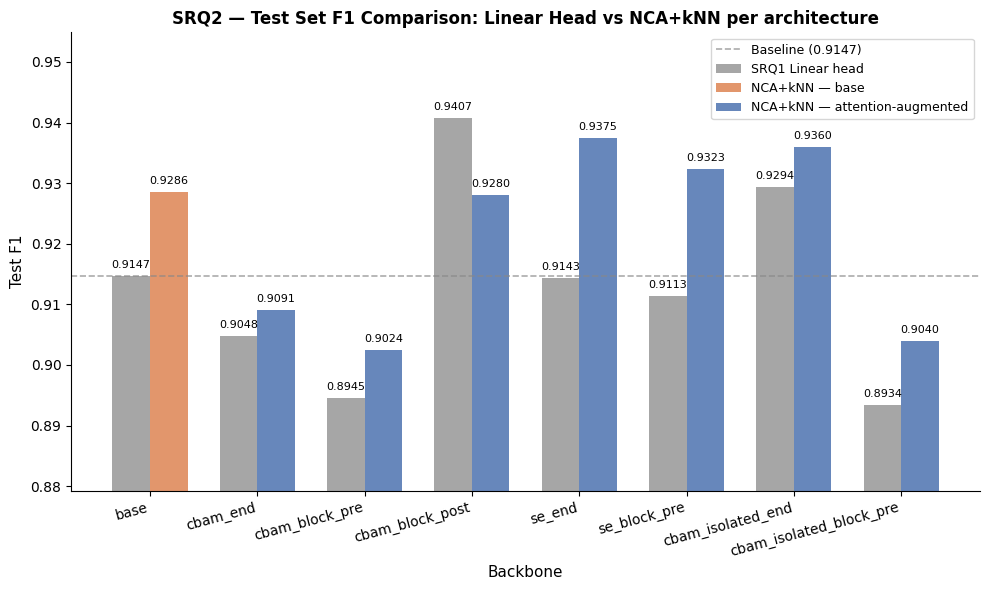

In [20]:
df_test_nca = pd.read_csv(TEST_RESULTS_FILE, index_col="backbone")

plot_backbones  = [b for b in BACKBONES if b in df_test_nca.index]
x               = np.arange(len(plot_backbones))
is_baseline     = np.array([b == "base" for b in plot_backbones])
width           = 0.35
baseline_f1_val = df_test_nca.loc["base", "linear_test_f1"] if "base" in df_test_nca.index else None
linear_vals     = [float(df_test_nca.loc[b, "linear_test_f1"]) for b in plot_backbones]
nca_vals        = [float(df_test_nca.loc[b, "test_f1"])        for b in plot_backbones]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, linear_vals, width, color="#888", alpha=0.75, label="SRQ1 Linear head")
ax.bar(x[ is_baseline] + width/2,
       [nca_vals[i] for i in np.where( is_baseline)[0]],
       width, color="#DD8452", alpha=0.85, label="NCA+kNN — base")
ax.bar(x[~is_baseline] + width/2,
       [nca_vals[i] for i in np.where(~is_baseline)[0]],
       width, color="#4C72B0", alpha=0.85, label="NCA+kNN — attention-augmented")
if baseline_f1_val:
    ax.axhline(baseline_f1_val, color="#888", linestyle="--",
               linewidth=1.2, alpha=0.7, label=f"Baseline ({baseline_f1_val:.4f})")
for i, (lv, nv) in enumerate(zip(linear_vals, nca_vals)):
    ax.text(i - width/2, lv + 0.001, f"{lv:.4f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, nv + 0.001, f"{nv:.4f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(plot_backbones, fontsize=10, rotation=15, ha="right")
ax.set_xlabel("Backbone", fontsize=11)
ax.set_ylabel("Test F1", fontsize=11)
ax.set_title("SRQ2 — Test Set F1 Comparison: Linear Head vs NCA+kNN per architecture", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
all_f1 = linear_vals + nca_vals
pad = (max(all_f1) - min(all_f1)) * 0.3 or 0.02
ax.set_ylim(max(0, min(all_f1) - pad), min(1, max(all_f1) + pad))

plt.tight_layout()
utils.save_fig(fig, PLOTS_DIR, "srq2_test_results", formats=("svg",))
plt.show()

## 9 · NCA+kNN Gain vs Linear Head F1 — Scatter Plot

Scatter plot of each backbone's linear-head test F1 (x-axis) against the NCA+kNN gain ΔF1 = NCA+kNN test F1 − linear test F1 (y-axis). Illustrates the inverse relationship discussed in the Discussion: backbones with lower linear-head performance tend to benefit more from the NCA+kNN pipeline.

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results\plots\srq2_gain_vs_linear_f1.svg


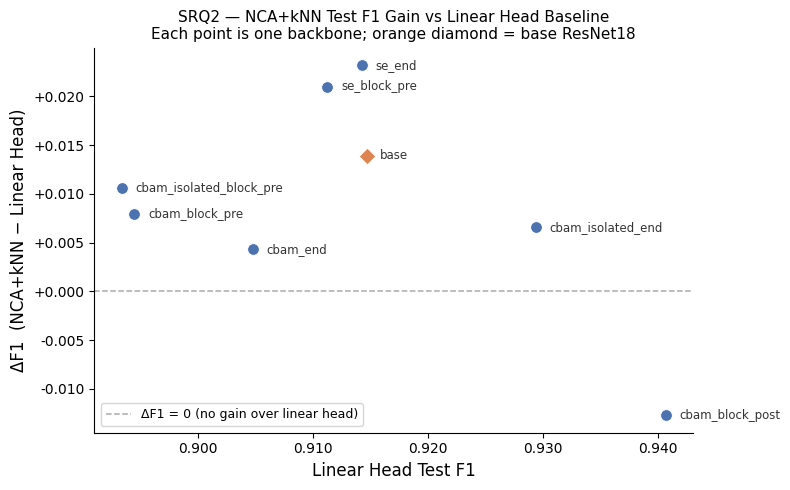

In [24]:
# ── NCA+kNN gain vs linear head F1 — scatter plot ────────────────────────────
# Requires: df_test_nca (from Section 8, index = backbone).

df_scatter = df_test_nca.copy()
df_scatter["delta_f1"] = df_scatter["test_f1"] - df_scatter["linear_test_f1"]

fig, ax = plt.subplots(figsize=(8, 5))

# Manual horizontal offsets only — labels are vertically centred on each point.
label_offsets = {
    "base":                    0.0012,
    "cbam_end":                0.0012,
    "cbam_block_pre":          0.0012,
    "cbam_block_post":         0.0012,
    "se_end":                  0.0012,
    "se_block_pre":            0.0012,
    "cbam_isolated_end":       0.0012,
    "cbam_isolated_block_pre": 0.0012,
}

for backbone, row in df_scatter.iterrows():
    colour = "#DD8452" if backbone == "base" else "#4C72B0"
    marker = "D"       if backbone == "base" else "o"
    ax.scatter(
        row["linear_test_f1"], row["delta_f1"],
        color=colour, s=72, zorder=3, marker=marker,
        edgecolors="white", linewidths=0.7
    )
    dx = label_offsets.get(backbone, 0.0012)
    ax.annotate(
        backbone,
        xy=(row["linear_test_f1"], row["delta_f1"]),
        xytext=(row["linear_test_f1"] + dx, row["delta_f1"]),
        fontsize=8.5, ha="left", va="center", color="#333"
    )

# Zero-gain reference line.
ax.axhline(0, color="#888", linestyle="--", linewidth=1.1, alpha=0.7,
           label="ΔF1 = 0 (no gain over linear head)")

ax.set_xlabel("Linear Head Test F1", fontsize=12)
ax.set_ylabel("ΔF1  (NCA+kNN − Linear Head)", fontsize=12)
ax.set_title(
    "SRQ2 — NCA+kNN Test F1 Gain vs Linear Head Baseline\n"
    "Each point is one backbone; orange diamond = base ResNet18",
    fontsize=11
)
ax.legend(fontsize=9, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%+.3f"))

plt.tight_layout()
utils.save_fig(fig, PLOTS_DIR, "srq2_gain_vs_linear_f1", formats=("svg",))
plt.show()